## Chapter 3. Classification

일반적인 지도 학습 작업 중 분류 시스템을 더 자세히 알아본다.

In [56]:
# 숫자 이미지 7만 개로 구성된 MNIST 데이터셋 사용하기

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
# 이미지 처리에 DataFrame은 적합하지 않으므로 as_frame=False 처리하여
# NumPy 배열로 반환하기

X, y = mnist.data, mnist.target
print(X)
print(X.shape)
print(y)
print(y.shape)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
(70000, 784)
['5' '0' '4' ... '4' '5' '6']
(70000,)


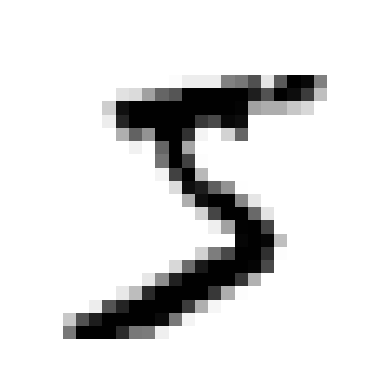

5


In [57]:
# 시각화

import matplotlib.pyplot as plt

def plot_digit(image_data):
	image = image_data.reshape(28, 28)
	plt.imshow(image, cmap="binary")
	plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show() # 5처럼 보이는 그림
print(y[0])

In [58]:
# 테스트셋 만들어두기(6:1 비율)
# MNIST 훈련 데이터셋은 이미 무작위로 섞여있다.

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [59]:
# 이진 분류기 학습: 숫자 5를 식별하기

y_train_5 = (y_train == '5') # 모든 숫자가 5이면 참, 아니면 거짓
y_test_5 = (y_test == '5')

In [60]:
# SGDClassifier: 확률적 경사 하강법 분류기
# 매우 큰 데이터셋을 효율적으로 처리할 수 있다.

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

sgd_clf.predict([some_digit]) # True로 예측 성공

array([ True])

In [61]:
# 분류기 성과 평가
# k-폴드 교차 검증: 교차 검증을 이용한 정확도 측정

from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")
# 출력 결과 95% 이상의 정확도 확인

array([0.95035, 0.96035, 0.9604 ])

In [62]:
# 더미 분류기

from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [63]:
# 이번엔 더미 분류기의 정확도 측정

cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")
# 출력결과 정확도가 약 90%이지만 
# 이것은 이미지 중 5가 나오는 비율이 약 10% 수준이기 때문이다. -> 불균형 데이터셋

array([0.90965, 0.90965, 0.90965])

In [64]:
# 데이터셋이 편향되어 있을 때 이처럼 정확한 평가가 어렵다.
# 따라서 분류기의 성능을 평가하는 더 좋은 방법은 오차 행렬을 살펴보는 것이다.
# 오차 행렬: 모든 A/B 쌍에 대해 클래스 A의 인스턴스가 클래스 B로 분류된 횟수 세기

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

# 먼저 실제 목표값과 비교할 수 있는 예측값 세트 준비
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
cm = confusion_matrix(y_train_5, y_train_pred)
print(cm)
# 출력 결과: [[53892, 687], [1891, 3530]]

[[53892   687]
 [ 1891  3530]]


In [65]:
# 만약 완벽하게 예측했다면 오차 행렬의 모습

y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)
# 출력 결과: [[54579, 0], [0, 5421]]

array([[54579,     0],
       [    0,  5421]])

#### 오차 행렬로 알 수 있는 정보

- 정밀도(precision):
##### precision = TP / (TP + FP)
TP는 참양성의 수이고, FP는 거짓양성의 수이다. 맞다고 한 것 중에 진짜가 얼마나 많은가.

- 재현율(recall):
##### recall = TP / (TP + FN)
FN은 거짓음성의 수이다. 실제 정답이 맞는 전체 대상 중에서,
모델이 놓치지 않고 재현하여 맞힌 비율. 실제 정답 중 얼마나 찾았나.

- F_1 점수:
##### F_1 = TP / (TP + ((FN + FP) / 2))
정밀도와 재현율 단일 지표로 결합

In [66]:
# Precision, Recall, F_1 score

from sklearn.metrics import precision_score, recall_score, f1_score

print(precision_score(y_train_5, y_train_pred)) # 약 0.84
print(recall_score(y_train_5, y_train_pred)) # 약 0.65
print(f1_score(y_train_5, y_train_pred)) # 약 0.73

0.8370879772350012
0.6511713705958311
0.7325171197343847


In [67]:
# 임계값 직접 제어하여, 정밀도와 재현율 조율

y_scores = sgd_clf.decision_function([some_digit])
print(y_scores)

threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred) # 임계값 0 이므로 predict() 메서드와 동일한 결과 True

threshold = 3000
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred) # 임계값을 높이면 재현율 감소한다는 것을 확인 False
# 모델이 직접 계산한 점수 수집
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
							 method="decision_function")

[2164.22030239]
[ True]
[False]


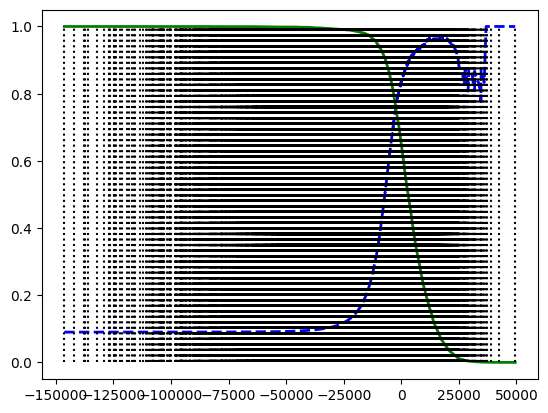

In [68]:
# 점수를 사용하여 precision_recall_curve()를 통해 가능한 모든 임계값에 대한
# 정밀도와 재현율 계산하기

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# 시각화
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(thresholds, 0, 1.0, "k", "dotted", label="threshold")
plt.show() # 정밀도 곡선이 재현율 곡선보다 더 울퉁불퉁하다.

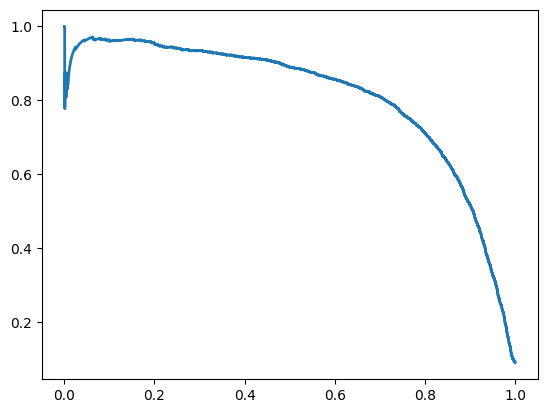

In [69]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.show() # 정밀도와 재현율 사이의 직접적인 관계
# 재현율이 약 0.8 정도부터 급격히 떨어지기 시작한다.
# 그 직전의 정밀도/재현율 균형을 선택하는 것이 좋다.

In [70]:
# 정밀도를 최소 0.9 이상으로 확보하기 위해 
# 설정해야 하는 최적의 결정 임계값 수치 찾아내기

idx_For_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_For_90_precision]
print(threshold_for_90_precision) # 약 3370

y_train_pred_90 = (y_scores >= threshold_for_90_precision)

print(precision_score(y_train_5, y_train_pred_90)) # 0.9 이상

recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
print(recall_at_90_precision) # 약 0.48

"""
약 90% 수준의 정밀도를 확보했지만, 이 때 재현율이 약 48% 수준으로 너무 낮다.
재현율이 너무 낮으면 정밀도가 높아도 유용하지 않은 분류기다.
"""

3370.0194991439557
0.9000345901072293
0.4799852425751706


'\n약 90% 수준의 정밀도를 확보했지만, 이 때 재현율이 약 48% 수준으로 너무 낮다.\n재현율이 너무 낮으면 정밀도가 높아도 유용하지 않은 분류기다.\n'

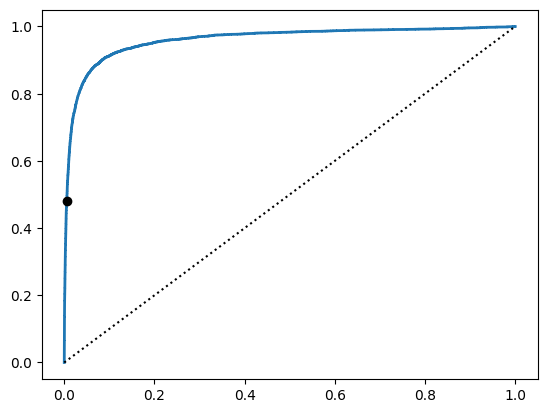

In [71]:
# ROC 곡선: 분류기가 임계값을 변동시킬 때 정밀도와 재현율 사이의 트레이드오프를
# 한눈에 보여주는 그래프
# tpr은 재현율이고, fpr은 거짓 양성 비율이다.

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.show()
# 재현율이 높을수록 오탐률이 높아지는 것을 확인
# 좋은 분류기는 선에서 최대한 멀리 떨어져 있는 것이다.(왼쪽 상단 모서리)

In [72]:
# ROC 곡선 아래쪽의 전체 면적(AUC)를 계산하여 모델의 성능을
# 0.0 부터 1.0 사이의 숫자로 요약해주는 코드

from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores) # 출력 결과: 약 0.96

0.9604938554008616

In [73]:
# 랜덤포레스트 분류기: 교차 방식으로 각 데이터가 5일 확률과 5가 아닐 확률을 구한다.

from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5,
									cv=3, method="predict_proba")

print(y_probas_forest[:2]) # 출력 결과: [[0.11 0.89], [0.99 0.01]]

[[0.11 0.89]
 [0.99 0.01]]


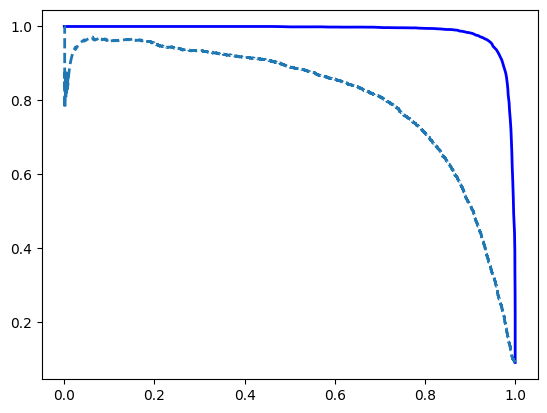

In [74]:
# 양성 확률만 뽑아, 정밀도-재현율 PR 곡선을 그리기 위한 값들 계산

y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
	y_train_5, y_scores_forest
)

# 시각화
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.show() # 실선인 랜덤포레스트가 SGD보다 훨씬 좋아 보인다.

In [75]:
# F_1 스코어와 AUC 스코어

y_train_pred_forest = y_probas_forest[:, 1] >= 0.5 # 양성 확률 50% 이상
print(f1_score(y_train_5, y_train_pred_forest))
# 0.9274509803921569
print(roc_auc_score(y_train_5, y_scores_forest))
# 0.9983436731328145
# f1과 auc 점수 또한 우수하다.

0.9274509803921569
0.9983436731328145


In [76]:
# 5만 분류하는 이진 분류기를 넘어 더 많은 것을 분류하는 다중 클래스 분류기
# SVC 활용하는 서포트 벡터 머신(SVM) 분류기(OvO)

from sklearn.svm import SVC
svm_clf = SVC(random_state=42)
# 학습 시간이 오래걸리는 걸 방지하기 위해 데이터 앞 2000개만 잘라서 쓰기
svm_clf.fit(X_train[:2000], y_train[:2000])

print(svm_clf.predict([some_digit]))
some_digit_scores = svm_clf.decision_function([some_digit])
print(some_digit_scores.round(2)) # 순서대로 숫자 0~9의 점수(확신도)
# 숫자 5에대한 점수가 9.3점으로 가장 높다.
class_id = some_digit_scores.argmax()
print(class_id) # 1등 점수의 인덱스: 5
print(svm_clf.classes_) # 학습한 클래스(숫자)
print(svm_clf.classes_[class_id])

['5']
[[ 3.79  0.73  6.06  8.3  -0.29  9.3   1.75  2.77  7.21  4.82]]
5
['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
5


In [77]:
# OvR: 1대다 전략을 사용하도록 강제 지정

from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

print(ovr_clf.predict([some_digit]))
print(len(ovr_clf.estimators_))

['5']
10


In [78]:
# SGDClassifier를 사용해 다중 클래스 데이터셋 학습
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
print(sgd_clf.predict([some_digit]))
# 결과가 3으로 실제 정답인 5와 다른 예측 오류 인것을 확인
# 각 클래스에 할당한 점수 확인
print(sgd_clf.decision_function([some_digit]).round())
# 예측에 대해 그다지 확신하지 못하고 있는 것을 확인

print(cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy"))
# 모든 테스트 폴드에서 85.8% 이상의 정확도 얻었다.

['3']
[[-31893. -19048.  -9531.   1824. -22320.  -1386. -26189. -16148.  -4604.
  -12051.]]
[0.87745 0.85835 0.8698 ]


In [79]:
# 입력값 스케일링 통한 성능 개선하기
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89835, 0.8902 , 0.90095])

c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


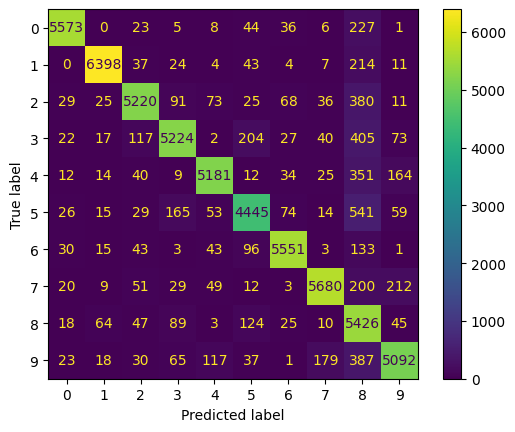

In [80]:
# 다중 클래스 분류 모델의 예측 성능을 한눈에 파악하기 위한 오차 행렬

from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show() # 상당히 양호해 보인다.

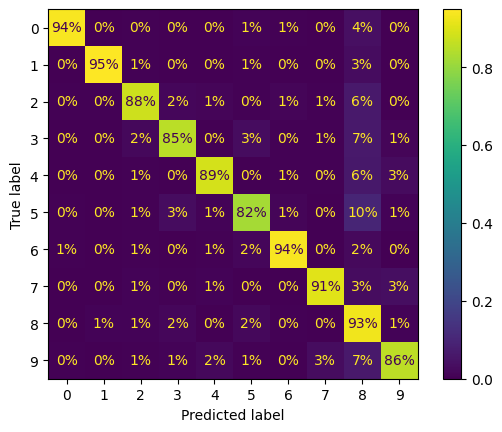

In [81]:
# 정규화

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.show()

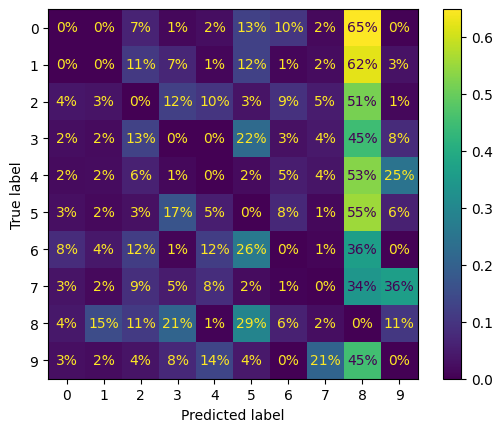

In [82]:
# 에러만 남겨서, 에러 패턴 보기

sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

In [83]:
# 에러 분석의 원인을 밝혀내기 위해, 실제 숫자 3과 5 이미지들을 여러 경우의 수로 분류하여 직접 비교

cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

In [84]:
# 다중 라벨 분류: 각 인스턴스에 대해 여러 클래스를 출력하도록 한다.

from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7') # 7이상인가?
y_train_odd = (y_train.astype('int8') % 2 == 1) # 홀수인가?
y_multilabel = np.c_[y_train_large, y_train_odd] # 두 라벨

knn_clf = KNeighborsClassifier() # 다중 라벨 학습 가능한 KNeighborsClassfier
knn_clf.fit(X_train, y_multilabel)

knn_clf.predict([some_digit])

array([[False,  True]])

In [85]:
# f1 스코어로 성능 측정

y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

In [86]:
# 분류기 체인을 통해, 다중 라벨 예측시 첫 라벨의 예측 결과를 두 번째 라벨 학습에 전달하는 구조

from sklearn.multioutput import ClassifierChain
chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

chain_clf.predict([some_digit])

array([[0., 1.]])

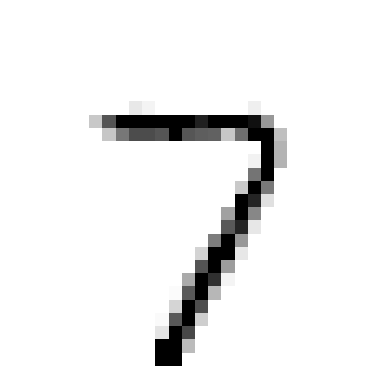

In [87]:
# 다중 출력 분류: 여러 라벨을 동시에 예측하는데, 각 라벨이 다중 클래스를 가질 수 있는 분류
# 원본 이미지에 무작위 노이즈(점)을 섞어서 지저분한 데이터를 만들고, 원본 이미지를 타깃으로 지정

rng = np.random.default_rng(seed=42)
noise_train = rng.integers(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise_train
noise_test = rng.integers(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise_test
y_train_mod = X_train
y_test_mod = X_test
# 다중 출력 분류를 통한 노이즈 제거
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()

In [ ]:
# Exercises
# 1. 그리드 서치를 활용하여 테스트셋에서 정확도 97% 이상 달성 MNIST 분류기 만들어보기

from sklearn.metrics import accuracy_score
# 탐색 그리드
param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5]}]

knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5, scoring="accuracy", verbose=3, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_knn_clf = grid_search.best_estimator_ # 최적 모델로 테스트셋 평가
y_pred = best_knn_clf.predict(X_test)

# 최종 정확도
test_accuracy = accuracy_score(y_test, y_pred)
print(test_accuracy)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ....n_neighbors=3, weights=uniform;, score=0.972 total time=  16.0s
[CV 2/5] END ....n_neighbors=3, weights=uniform;, score=0.971 total time=  15.6s
[CV 3/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time=  16.4s
[CV 4/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time=  15.8s
[CV 5/5] END ....n_neighbors=3, weights=uniform;, score=0.970 total time=  15.8s
[CV 1/5] END ...n_neighbors=3, weights=distance;, score=0.972 total time=  15.9s
[CV 2/5] END ...n_neighbors=3, weights=distance;, score=0.972 total time=  16.0s
[CV 3/5] END ...n_neighbors=3, weights=distance;, score=0.970 total time=  16.3s
[CV 4/5] END ...n_neighbors=3, weights=distance;, score=0.970 total time=  16.0s
[CV 5/5] END ...n_neighbors=3, weights=distance;, score=0.971 total time=  15.9s
[CV 1/5] END ....n_neighbors=4, weights=uniform;, score=0.969 total time=  16.4s
[CV 2/5] END ....n_neighbors=4, weights=uniform;,

In [ ]:
# 2. 데이터 증식을 통해 테스트셋 정확도 더 개선하기

from scipy.ndimage import shift

# 이미지 상하좌우 이동시키는 함수
def shift_image(image, dx,dy):
	image = image.reshape(28, 28)
	shifted_image = shift(image, [dy, dx], cval=0) # 픽셀 이동
	return shifted_image.reshape(-1) # 1차원 배열로 펼쳐서 반환
# 데이터 증식
X_train_aug = [image for image in X_train]
y_train_aug = [label for label in y_train]

shift_directions = [(1, 0), (-1, 0), (0, 1), (0, -1)] # 이동 방향 설정
for dx, dy in shift_directions:
	for image, label in zip(X_train, y_train):
		X_train_aug.append(shift_image(image, dx, dy))
		y_train_aug.append(label)
# numpy 배열 변환
X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

knn_clf_aug = KNeighborsClassifier(n_neighbors=4, weights='distance', n_jobs=-1)
knn_clf_aug.fit(X_train_aug, y_train_aug)

y_pred = knn_clf_aug.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(test_accuracy) # 정확도 출력


0.9763


In [4]:
# 3. Kaggle Titanic Dataset 이용한 승선객 생존여부 예측 분류기

import os
import urllib.request
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

# 데이터 저장할 경로 및 다운로드 URL
titanic_PATH = os.path.join("datasets", "titanic")
TRAIN_URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/titanic/train.csv"
TEST_URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/titanic/test.csv"
# 데이터 다운로드 함수
def prepare_titanic_data(path=titanic_PATH):
	if not os.path.isdir(path):
		os.makedirs(path)
	train_csv_path = os.path.join(path, "train.csv")
	if not os.path.isfile(train_csv_path):
		urllib.request.urlretrieve(TRAIN_URL, train_csv_path)

	test_csv_path = os.path.join(path, "test.csv")
	if not os.path.isfile(test_csv_path):
		urllib.request.urlretrieve(TEST_URL, test_csv_path)	

prepare_titanic_data()

# CSV 불러오기
def load_titanic_data(filename, path=titanic_PATH):
	csv_path = os.path.join(path, filename)
	return pd.read_csv(csv_path)

train_data = load_titanic_data("train.csv")
test_data = load_titanic_data("test.csv") # test.csv를 로드하긴 했지만, 사실 Survived열이 존재하지 않는다.

print(test_data.info())

# 피쳐 및 타깃 분리
X_train = train_data.drop("Survived", axis=1)
y_train = train_data["Survived"].copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None


In [ ]:
# 전처리

# 수치형 특성 전처리
num_pipeline = Pipeline([
	("imputer", SimpleImputer(strategy="median")), # 중간값으로 결측치 채우기
	("scaler", StandardScaler())
])

# 범주형 특성 전처리
cat_pipeline = Pipeline([
	("imputer", SimpleImputer(strategy="most_frequent")), # 결측치 최빈값으로 채우기
	("cat_encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

num_attribs = ["Age", "SibSp", "Parch", "Fare"]
cat_attribs = ["Pclass", "Sex", "Embarked"]

# 전처리 파이프라인 합치기
preprocess_pipeline = ColumnTransformer([
	("num", num_pipeline, num_attribs),
	("cat", cat_pipeline, cat_attribs)
])

X_train_prepared = preprocess_pipeline.fit_transform(X_train)

In [ ]:
# 모델 생성, 학습

forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
# test.csv에 Survived 컬럼이 없기 때문에 교차 검증을 통해 성능을 본다.
forest_score = cross_val_score(forest_clf, X_train_prepared, y_train, cv=10)
# 교차 검증의 정확도
print(forest_score)

[0.75555556 0.79775281 0.76404494 0.80898876 0.88764045 0.83146067
 0.83146067 0.7752809  0.84269663 0.84269663]


In [ ]:
# 4. 스팸 분류기

import email
import email.policy
from sklearn.linear_model import LogisticRegression
import tarfile

download_url = "https://spamassassin.apache.org/old/publiccorpus/"
ham_url = download_url + "20030228_easy_ham.tar.bz2"
spam_url = download_url + "20030228_spam.tar.bz2"
spam_PATH = os.path.join("datasets", "spam")
# 데이터 다운로드
def prepare_spam_data(ham_url=ham_url, spam_url=spam_url, spam_path=spam_PATH):
	if not os.path.isdir(spam_path):
		os.makedirs(spam_path)
	for url, filename in [(ham_url, "ham.tar.bz2"), (spam_url, "spam.tar.bz2")]:
		path = os.path.join(spam_path, filename)
		if not os.path.isfile(path):
			urllib.request.urlretrieve(url, path)
		tar_file = tarfile.open(path)
		tar_file.extractall(path=spam_path)
		tar_file.close()

prepare_spam_data()

# 이메일 로드
def load_email(is_spam, filename, spam_path=spam_PATH):
	directory = "spam" if is_spam else "easy_ham"
	path = os.path.join(spam_path, directory, filename)
	with open(path, "rb") as f:
		return email.parser.BytesParser(policy=email.policy.default).parse(f)

ham_filenames = [name for name in os.listdir(os.path.join(spam_PATH, "easy_ham")) if len(name) > 20]
spam_filenames = [name for name in os.listdir(os.path.join(spam_PATH, "spam")) if len(name) > 20]

ham_emails = [load_email(is_spam=False, filename=name) for name in ham_filenames]
spam_emails = [load_email(is_spam=True, filename=name) for name in spam_filenames]

# 훈련, 테스트셋 분리
X = np.array(ham_emails + spam_emails, dtype=object)
y = np.array([0] * len(ham_emails) + [1] * len(spam_emails))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\lbjic\AppData\Local\Temp\ipykernel_40216\2210207146.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_file.extractall(path=spam_path)


In [99]:
# 이메일 텍스트 전처리 변환기

import re
import urlextract
import nltk

try:
    stemmer = nltk.PorterStemmer()
except ImportError:
    stemmer = None

url_extractor = urlextract.URLExtract()

# 이메일을 텍스트로 변환하는 커스텀 사이킷런 변환기
class EmailToWordCounterTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, strip_headers=True, lower_case=True, replace_urls=True,
                 replace_numbers=True, remove_punctuation=True, stemming=True):
        self.strip_headers = strip_headers
        self.lower_case = lower_case
        self.replace_urls = replace_urls
        self.replace_numbers = replace_numbers
        self.remove_punctuation = remove_punctuation
        self.stemming = stemming

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_transformed = []
        for mail in X:
            # 본문 텍스트 추출
            text = ""
            for part in mail.walk():
                ctype = part.get_content_type()
                if ctype in ("text/plain", "text/html"):
                    try:
                        content = part.get_content()
                    except:
                        content = str(part.get_payload())
                    if ctype == "text/plain":
                        text += content
                    else:
                        text += re.sub(r'<[^>]+>', ' ', content) # HTML 태그 제거
            
            # 소문자화
            if self.lower_case:
                text = text.lower()

            # URL 치환
            if self.replace_urls and url_extractor:
                urls = list(set(url_extractor.find_urls(text)))
                urls.sort(key=lambda url: len(url), reverse=True)
                for url in urls:
                    text = text.replace(url, " URL ")

            # 숫자 치환
            if self.replace_numbers:
                text = re.sub(r'\d+(?:\.\d+)?', ' NUMBER ', text)

            # 문장부호 제거
            if self.remove_punctuation:
                text = re.sub(r'\W+', ' ', text, flags=re.M)

            # 어간 추출 및 단어 개수 세기
            word_counts = {}
            tokens = text.split()
            for word in tokens:
                if self.stemming and stemmer:
                    word = stemmer.stem(word)
                word_counts[word] = word_counts.get(word, 0) + 1

            X_transformed.append(word_counts)
        return X_transformed

In [100]:
# 희소 행렬 변환기, 전체 파이프라인

from scipy.sparse import csr_matrix

class WordCounterToVectorTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, vocabulary_size=1000):
        self.vocabulary_size = vocabulary_size

    def fit(self, X, y=None):
        total_counts = {}
        for word_dict in X:
            for word, count in word_dict.items():
                total_counts[word] = total_counts.get(word, 0) + count
        # 가장 자주 등장하는 단어 상위  선정
        most_common = sorted(total_counts.items(), key=lambda x: x[1], reverse=True)[:self.vocabulary_size]
        self.vocabulary_ = {word: i for i, (word, count) in enumerate(most_common)}
        return self

    def transform(self, X, y=None):
        rows, cols, data = [], [], []
        for row, word_dict in enumerate(X):
            for word, count in word_dict.items():
                if word in self.vocabulary_:
                    rows.append(row)
                    cols.append(self.vocabulary_[word])
                    data.append(count)
        return csr_matrix((data, (rows, cols)), shape=(len(X), self.vocabulary_size))

# 전처리 및 모델 연결 파이프라인
preprocess_pipeline = Pipeline([
    ("email_to_words", EmailToWordCounterTransformer()),
    ("word_to_vector", WordCounterToVectorTransformer(vocabulary_size=1000)),
])

X_train_transformed = preprocess_pipeline.fit_transform(X_train)

log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train_transformed, y_train)

# 테스트셋 평가
X_test_transformed = preprocess_pipeline.transform(X_test)
y_pred = log_clf.predict(X_test_transformed)

print(precision_score(y_test, y_pred)) # 정밀도
print(recall_score(y_test, y_pred)) # 재현율

0.96875
0.9789473684210527


## Chapter 4. Training Models

지금까지는 머신러닝 알고리즘의 내부 작동 방식에 대해 아무것도 모른 채 블랙박스로 다뤘다.
이 장에서는 디버깅 및 오류 분석을 더욱 효율적으로 수행하기 위한 내부 작동 방식을 이해할 수 있도록 모델 훈련하는 방법을 다룬다.

#### 선형 회귀 모델

- 훈련 세트에 가장 적합한 모델 매개변수를 직접 계산하는 폐쇄형 방정식을 사용한다.
- 경사 하강법(GD)이라는 반복적 최적화 접근 방식을 사용해 훈련 세트에 비용 함수를 최소화하도록
모델 매개변수를 점진적으로 조정하며, 첫 방법과 동일한 매개변수 집합으로 수렴한다.

- 삶의 만족도에 대한 간단한 선형 모델
##### life_satisfaction = θ_0 + θ_1 * GDP_per_capita
1인당 GDP에 대한 선형 함수이다.

- 선형 회귀 모델 예측
##### y_hat = θ_0 + θ_1 * x_1 + θ_2 * x_2 + ⋯ + θ_n * x_n
y_hat은 예측값이고, n은 피쳐 개수, x_i는 i번째 피쳐, 
θ_j는 편향항 θ_0와 특성 가중치를 포함하는 j번째 모델 매개변수다.

- 위 예측식의 벡터화 형태
##### y_hat = h_θ(x) = θ·x
내적하면 위 식과 같다.

- 모델 훈련이란 모델이 훈련 데이터셋에 가장 잘 맞도록 매개변수를 설정하는 것이다.
먼저 측정 지표부터 선택해야 한다. 앞서 다뤘던 RMSE를 최소화 하는 것보다
평균 제곱 오차(MSE)(루트를 씌우지 않음)를 최소화하는 것이 더 간단하며, 결과는 동일하다.

##### MSE(X, y, h_0) = 1 / m * sum((θ^T * x(i) - y(i)) ^ 2)

- MSE를 최소화하는 θ값을 찾기 위한 방정식
##### θ_hat = ((X^T * X) ^ (-1)) * X^T * y

#### 다항 회귀 모델

- 선형 회귀보다 매개변수가 많기 때문에 훈련 데이터에 과적합될 가능성이 더 높다.

In [101]:
# MSE를 최소화하는 θ값을 찾기 위한 방정식
# θ_hat = ((X^T * X) ^ (-1)) * X^T * y

from sklearn.preprocessing import add_dummy_feature

rng = np.random.default_rng(seed=42)
m = 200 # 인스턴스 수
X = 2 * rng.random((m, 1)) # 열 벡터
y = 4 + 3 * X + rng.standard_normal((m, 1)) # 열 벡터

X_b = add_dummy_feature(X) # 벡터화를 위해 모든 데이터 행에 x_0 = 1 추가
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print(theta_best)
# 출력결과 기대한 θ_0 = 4, θ_1 = 3과 다르다. 노이즈 때문에 원래 함수의
# 정확한 매개변수를 복원하는 것이 어려웠다.

# θ_hat을 이용한 예측
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
print(y_predict)

[[3.69084138]
 [3.32960458]]
[[ 3.69084138]
 [10.35005055]]


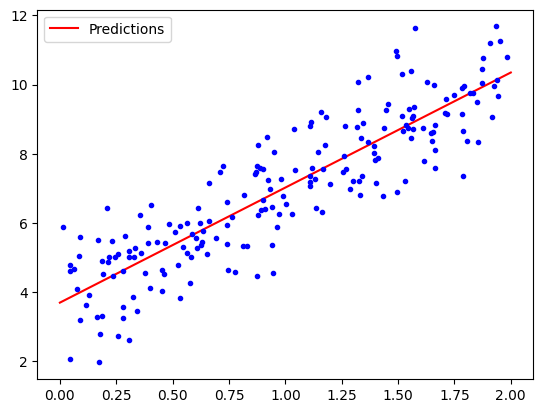

In [102]:
# 시각화

plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")
plt.legend(loc="upper left")
plt.show()

In [103]:
# 선형 회귀 분석

lin_reg = LinearRegression()
lin_reg.fit(X, y)
print(lin_reg.intercept_, lin_reg.coef_) # 편향과 가중치
print(lin_reg.predict(X_new))

[3.69084138] [[3.32960458]]
[[ 3.69084138]
 [10.35005055]]


In [104]:
# SVD(특이값 분해)를 이용해 유사역행렬을 구한 뒤 최적 파라미터를 산출

theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
print(theta_best_svd)

print(np.linalg.pinv(X_b) @ y)

# 시간 복잡도 측면에서 정규방정식보다 SVD방식이 더 빠르다.
# 최적 파라미터 구하기에 SVD가 더 유리하다.

[[3.69084138]
 [3.32960458]]
[[3.69084138]
 [3.32960458]]


#### 경사 하강법

경사 하강법은 광범위한 문제에 대한 최적해를 찾을 수 있는 범용 최적화 알고리즘이다.
비용 함수를 최소화하기 위해 매개변수를 반복적으로 조정한다.
비용 함수의 기울기가 0인 지점이 바로 오차가 최소가 되는 최저점이다.
그 최저점을 경사가 가장 가파른 방향으로 내려가는 것이 가장 좋은 전략이다.
먼저 θ에 임의의 값을 채워 넣고, 한 번에 한 단계씩, 각 단계에서 비용 함수를
줄이려고 시도하면서 점진적으로 개선해 나가고, 알고리즘이 최소값으로 수렴할 때까지 반복한다.
학습률 하이퍼파라미터에 의해 결정되는 경사를 내려가는 보폭의 크기가 중요하다.
학습률이 너무 작으면 너무 많은 반복을 거쳐야 하므로 시간이 오래걸린다.
반대로 너무 높으면 최저점을 뛰어넘어 반대편에 도달하는 문제가 발생할 수 있다.
모든 비용 함수가 깔끔한 이차함수 모양인 것은 아니다. 선형 회귀 모델의 MSE 비용 함수는
다행히 볼록 함수이다.
수렴하는데 너무 오랜 시간이 걸리지 않으려면 모든 특징점의 스케일이 유사해야 한다.

#### 배치 경사 하강법

경사 하강법과 다르게 θ를 단 한 번 이동할 때 딱 한 개가 아니라 전체 훈련 데이터셋
모두를 끌어모아 기울기를 계산한다.

- 비용 함수의 편미분
##### ∂/∂θ_j MSE(θ) = (2 / m) * Σ [i=1 to m] (θ^T * x^(i) - y^(i)) * x_j^(i)
개별 파라미터 딱 1개에 대해서만 MSE 비용 함수가 얼마나 변하는지 구하는 수식

- 비용 함수의 그라디언트 벡터
##### ∇_θ MSE(θ) = [ ∂/∂θ_0 MSE(θ), ∂/∂θ_1 MSE(θ), ..., ∂/∂θ_n MSE(θ) ]^T
#####           = (2 / m) * X^T * (X * θ - y)
편미분값들을 하나의 열벡터로 묶고, 행렬 곱셈으로 단 한 번에 계산

- 경사 하강법의 파라미터 업데이트 수식
##### θ_(next step) = θ - η * ∇_θ MSE(θ)
구한 가장 가파르게 올라가는 기울기(그라디언트)를 기반으로 현재 파라미터를 어느 방향으로, 얼마나 이동시킬지 결정

In [105]:
# θ_(next step) = θ - η * ∇_θ MSE(θ)
# 에포크는 훈련 데이터셋을 반복하는 각 단계

eta = 0.1 # 학습률
n_epochs = 1000
m = len(X_b) # 인스턴스 수

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1)) # 무작위로 초기화된 모델 매개변수

for epoch in range(n_epochs):
	gradients = 2 / m * X_b.T @ (X_b @ theta - y)
	theta = theta - eta * gradients

print(theta)

[[3.69084138]
 [3.32960458]]


#### 확률적 경사 하강법

배치 경사 하강법의 주요 문제인 훈련 데이터셋 전체를 매 단계마다 사용한다는 점을 고려하여 개발되었다.
매 스텝마다 전체 데이터셋이 아니라 무작위로 딱 1개의 데이터만 추출하여 그라디언트를 계산하고
파라미터를 업데이트한다. 따라서 대규모 훈련 데이터셋에서도 학습이 가능하다.
반면, 무작위적 특성 때문에 배치 경사 하강법보다 훨씬 불규칙적이다.
이 무작위성은 지역 최적점에서 벗어나는 데는 유용하지만, 결코 최소값에
수렴하지 못한다는 단점이 있다. 이를 해결하기 위해 학습률을 점진적으로 줄인다.

In [106]:
# 간단한 학습 스케줄을 사용하여 확률적 경사 하강법 구현

n_epochs = 50
t0, t1 = 5, 50 # 학습 스케쥴 하이퍼파라미터

def learning_schedule(t):
	return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1)) # 무작위로 초기화된 매개변수

for epoch in range(n_epochs):
	for iteration in range(m):
		random_index = rng.integers(m)
		xi = X_b[random_index : random_index + 1]
		yi = y[random_index : random_index + 1]
		gradients = 2 * xi.T @ (xi @ theta - yi)
		eta = learning_schedule(epoch * m + iteration)
		theta = theta - eta * gradients

print(theta) # 1,000번 반복하는 배치 경사 하강법에 비해 50번만으로 상당히 좋은 해 얻음

[[3.69826475]
 [3.30748311]]


In [107]:
# 확률적 경사 하강법(SGD) 방식으로 선형 회귀 모델 학습

from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
					   n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())
print(sgd_reg.intercept_, sgd_reg.coef_) # 최적 편향 및 가중치

[3.68899733] [3.33054574]


#### 미니 배치 경사 하강법

앞서 다룬 배치 경사 하강법과 확률적 경사 하강법의 장점만 결합한 알고리즘이다.
미니 배치를 기반으로 기울기를 계산한다. 특히 GPU를 사용할 때 행렬 연산의 하드웨어 가속을 통해
성능 향상을 얻을 수 있다. 확률적 경사 하강법보다 매개변수 공간에서의 진행이 덜 불규칙적이다.

#### 다항 회귀

데이터가 단순히 직선 형태가 아니라 곡선처럼 복잡한 형태를 띨 때, 각 특성의 거듭제곱을 새로운
특성으로 추가하여 선형 모델을 학습시킨다.

In [108]:
# 이차방정식 + 노이즈 형태의 데이터

rng = np.random.default_rng(seed=42)
m = 200
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + rng.standard_normal((m, 1))

In [109]:
# PolynomialFeatures를 통해 위 데이터를 변환

from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
print(lin_reg.intercept_, lin_reg.coef_)

[1.64373629]
[0.00540719] [[0.11022126 0.50526985]]


#### 학습 곡선

훈련 반복 횟수가 늘어남에 따라 모델의 훈련, 검증 오차가 어떻게 변화하는지 나타낸 곡선이다.
모델이 학습 곡선을 따라가지 못하면 과적합된 것이다. 점진적 학습 방식을 사용하는 경우,
학습 데이터셋의 하위 집합을 점진적으로 늘려가며 여러 번 학습해야 한다.

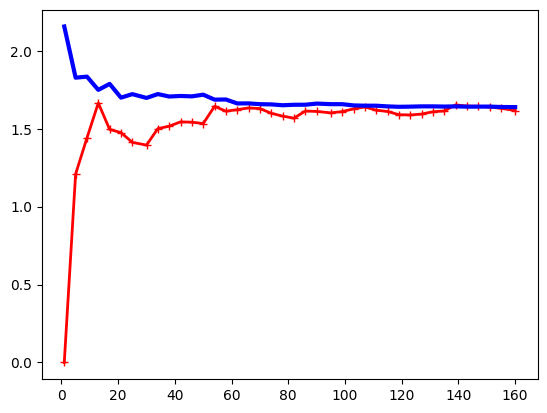

In [110]:
# Scikit-Learn의 learning_curve() 함수

from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()
# 모델이 데이터에 비해 너무 단순해서 과소적합된 것을 확인

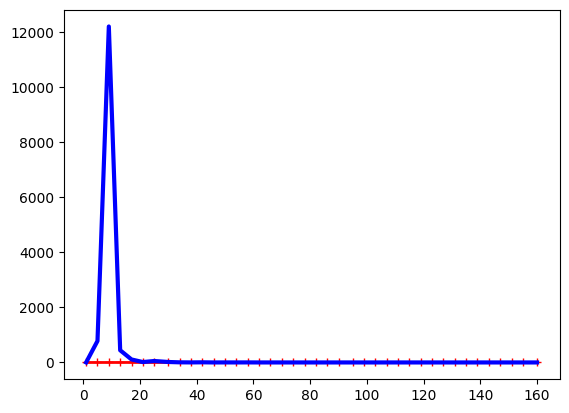

In [111]:
# 동일한 데이터에 대해 10차 다항식 모델의 학습 곡선을 살펴본다.

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()
# 훈련 데이터에 대한 오류가 훨씬 낮아졌다. 또한 두 곡선 사이에 간격이 생겼다.
# 이것은 모델이 검증 데이터보다 훈련 데이터에서 더 나은 성능을 보인다는 것이고,
# 과적합을 의미한다.

#### 편향/분산 트레이드오프

- 편향: 일반화 오류의 일부로, 데이터에 대한 잘못된 가정에서 비롯된다.
편향이 높은 모델은 훈련 데이터에 과소적합될 가능성이 높다.

- 분산: 모델이 훈련 데이터의 변화에 너무 민감하기 때문에 발생하는 문제다.
분산이 높은 모델은 훈련 데이터에 과적합될 가능성이 크다.

- 줄일 수 없는 오류: 데이터 자체의 노이즈 때문에 발생한다.
유일한 줄이는 방법은 데이터를 정리하는 것이다.

모델의 복잡성을 높이면 보통 분산이 증가하고 편향이 감소한다.
반대로 낮추면 편향이 증가하고 분산이 감소한다.

#### 규제 선형 모델

모델의 과적합을 방지하기 위해 비용 함수에 가중치의 크기에 대한 페널티를 추가한 선형 회귀 모델

#### 릿지 회귀

선형 회귀의 비용 함수에 가중치들의 제곱합(L2 노름)에 비례하는 페널티를 추가한 규제 모델
- 릿지 회귀 비용 함수
##### J(θ) = MSE(θ) + α * m * sum(θ_i^2)
- 릿지 회귀 가중치를 한 번에 계산하는 정규 방정식
##### θ_hat = (X^T * X + αA)^(-1) * X^T * y

In [112]:
from sklearn.linear_model import Ridge
# 정규 방정식, θ_hat = (X^T * X + αA)^(-1) * X^T * y
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
print(ridge_reg.predict([[1.5]]))
# 확률적 경사 하강법
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
					   max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())
print(sgd_reg.predict([[1.5]]))

[1.56184764]
[1.56234968]


#### 라쏘 회귀

선형 회귀 비용 함수에 가중치들의 절댓값 합(L1 노름)을 페널티로 더한 규제 모델
- 라쏘 회귀 비용 함수
##### J(θ) = MSE(θ) + 2α * sum(|θ_i|)

경사 하강법이 최적점 주변에서 맴도는 현상을 방지하기 위해 학습률을 점진적으로 줄인다.
- 라쏘 회귀 서브그라디언트 벡터
##### g(θ) = ∇_θ MSE(θ) + α * [ sign(θ_1), sign(θ_2), ..., sign(θ_n) ]^T
경사 하강법으로 학습시킬 때 사용하는 서브그라디언트 벡터 수식

In [113]:
# 라쏘

from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
print(lasso_reg.predict([[1.5]]))

[1.50803756]


#### 엘라스틱 넷 회귀

릿지와 라쏘의 규제 항목을 결합하여 사용하는 규제 선형 모델
- 엘라스틱 넷 비용 함수
##### J(θ) = MSE(θ) + r * (2 * α * Σ [i=1 to n] |θ_i|) + (1 - r) * ((α / m) * Σ [i=1 to n] (θ_i)^2)

In [114]:
# 엘라스틱 넷
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
print(elastic_net.predict([[1.5]]))

[1.53339604]


#### 조기 종료

경사 하강법처럼 반복적으로 모델을 학습시키는 알고리즘에서 검증 오류가 최소에 도달했을 때
학습을 조기에 중단하는 규제이다. 과적합을 완화할 수 있다.

In [115]:
# 조기 종료

from copy import deepcopy

X_train, y_train, X_valid, y_valid = [...] # 2차 데이터셋 분할

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

ValueError: not enough values to unpack (expected 4, got 1)

#### 로지스틱 회귀

샘플이 특정 클래스에 속할 확률을 추정하여 이진 분류하는 선형 알고리즘
- 로지스틱 회귀 확률 추정 가설 함수
##### p_hat = h_θ(x) = σ(θ^T * x)
입력 특성 벡터가 주어졌을 때 샘플이 양성 클래스에 속할 확률을 추정하는 함수
- 로지스틱 함수
##### σ(t) = 1 / (1 + exp(-t))
- 최종 클래스를 결정하는 임계값 조건식
##### y_hat = 0  (if p_hat < 0.5)
#####        1  (if p_hat >= 0.5)
- 단일 훈련 샘플에 대한 비용 함수
##### c(θ) = -log(p_hat)       (if y = 1)
#####       -log(1 - p_hat)   (if y = 0)
단일 훈련 샘플에 대한 손실을 계산하는 조건부 손실 함수 수식이다.
- 비용 함수(로그 손실)
##### J(θ) = -(1 / m) * Σ [i=1 to m] [ y^(i) * log(p_hat^(i)) + (1 - y^(i)) * log(1 - p_hat^(i)) ]
전체 데이터셋에 대한 비용 함수인 로그 손실 수식이다.
- 로지스틱 비용 함수의 편미분
##### ∂/∂θ_j J(θ) = (1 / m) * Σ [i=1 to m] ( σ(θ^T * x^(i)) - y^(i) ) * x_j^(i)

In [116]:
# 아이리스 데이터셋을 통한 로지스틱 회귀

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris(as_frame=True)

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == "virginica"
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

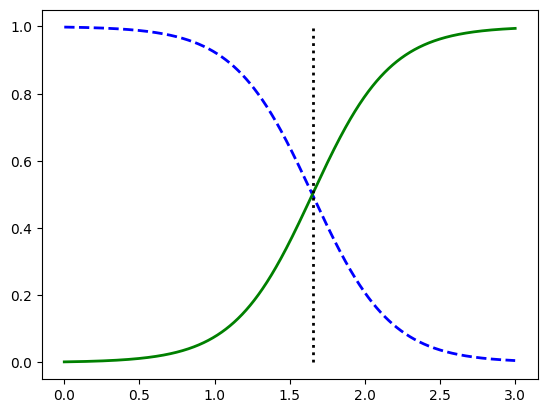

In [117]:
# 꽃잎 너비가 0~3cm까지 다양한 꽃에 대한 모델 추정 확률 살펴보기

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

plt.show()

In [118]:
# 예측 클래스 확인

print(decision_boundary)
print(log_reg.predict([[1.7], [1.5]]))

1.6516516516516517
[ True False]


#### 소프트맥스 회귀

이진 분류만 가능한 로지스틱 회귀와 달리 3개 이상의 클래스를 한번에 분류할 수 있는 선형 다중 분류 알고리즘
- 클래스 k에 대한 소프트맥스 스코어
##### s_k(x) = (θ^(k))^T * x
- 소프트맥스 함수
##### p_hat_k = σ(s(x))_k = exp(s_k(x)) / Σ [j=1 to K] exp(s_j(x))
- 소프트맥스 회귀 분류기 예측
##### y_hat = argmax_k σ(s(x))_k 
#####      = argmax_k s_k(x) 
#####      = argmax_k ( (θ^(k))^T * x )
가장 높은 점수를 받은 클래스가 가장 높은 소프트맥스 확률을 얻는다.
- 크로스 엔트로피 비용 함수
##### J(Θ) = -(1 / m) * Σ [i=1 to m] Σ [k=1 to K] y_k^(i) * log(p_hat_k^(i))
k개의 다중 클래스에 대한 비용 함수
- 클래스 k의 크로스 엔트로피 그라디언트 벡터 수식
##### ∇_θ^(k) J(Θ) = (1 / m) * Σ [i=1 to m] ( p_hat_k^(i) - y_k^(i) ) * x^(i)
크로스 엔트로피 비용함수를 클래스 k의 가중치벡터로 편미분한 그라디언트 벡터 수식

In [119]:
# 소프트맥스 회귀를 사용하여 아이리스 식물 세 가지 클래스로 분류

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)
# 꽃잎 길이가 5cm, 너비가 2cm인 붓꽃
print(softmax_reg.predict([[5, 2]]))
print(softmax_reg.predict_proba([[5, 2]]).round(2))

[2]
[[0.   0.04 0.96]]


#### Exercises

1. 수백만 개의 피쳐가 있는 훈련셋이 있다면 어떤 선형 회귀 알고리즘을 사용해야 하나: 확률적 경사 하강법

2. 훈련 세트의 피쳐 스케일이 서로 다를 때, 어떤 알고리즘들이 영향을 받고 어떻게 해결해야 하나: 
경사 하강법과 거리 기반의 알고리즘이 영향을 받고, 해결하기 위해 학습 전에 피쳐 스케일링(표준화, 정규화 등)을 진행해야 한다.

3. 로지스틱 회귀 모델을 학습할 때 경사 하강법이 지역 최소값에 갇힐 수 있나: 
로지스틱 회귀는 비용 함수인 로그 손실이 볼록 함수이기 때문에 지역 최소값이 곧 전역 최솟값이다.

4. 경사 하강법은 충분한 시간 동안 실행하면 모두 동일한 결과를 얻나:
경사 하강법의 종류, 하이퍼파라미터, 비용 함수의 형태에 따라 결과가 다르다.

5. 배치 경사 하강법을 사용하고 매 에포크마다 검증 오류를 그래프로 나타낸다고 할 때,
검증 오류가 지속적으로 증가한다면, 무엇이 원인이고, 어떻게 해결하나:
학습률이 너무 커서 최저점을 넘어서 건너편으로 뛰어넘어 오류가 생길 수 있고, 이 때 학습률을 줄여야 한다.

6. 미니 배치 경사 하강법에서 검증 오류가 증가할 때 즉시 중단하는 것이 좋은 생각인가:
즉시 중단해버리면, 실제 최저점에 도달하기 전에 오차가 튄 지점에서 끝나버린다. 

7. 경사 하강법 중 어떤 알고리즘이 최적해 근처에 가장 빨리 도달하나, 실제로 수렴하는 알고리즘은 무엇인가,
나머지 알고리즘들도 수렴하려면 어떻게 해야 하나:
가장 빨리 도달하는 알고리즘은 스텝마다 데이터 1개만 쓰는 확률적 경사하강법이고, 
실제로 완전히 수렴하는 알고리즘은 전체 데이터를 써서 무작위성이 없는 배치 경사 하강법이다.
SGD와 미니 배치 경사 하강법은 학습률을 점진적으로 줄여주는 학습 스케쥴이 필요하다.

8. 다항 회귀를 사용할 때 학습 곡선을 그렸더니 훈련 오차와 검증 오차 사이 큰 격차가 존재한다면,
어떤 현상이 발생한 것이고, 어떻게 해결하나:
훈련 데이터에 과적합이 발생한 것이고, 다항 회뤼의 차수를 줄여 복잡도를 낮추거나,
규제를 적용하거나, 더 많은 훈련 데이터를 넣는다.

9. 릿지 회귀를 사용할 때 훈련 오류와 검증오류가 거의 같고 상당히 높다면, 모델이 높은 편향
또는 높은 분산 문제를 겪고 있는가, 정규화 하이퍼파라미터 α를 높여야 하나 줄여야 하나:
높은 편향(과소적합)문제이고, 하이퍼파라미터 α(규제의 강도)를 줄여야 한다.

10. 단순 선형 회귀 대신 릿지를 쓰는 이유: 단순 선형 회귀는 과적합 발생이 쉽지만, 릿지는
L2 규제 페널티가 비용 함수에 추가되어 분산을 줄여 과적합을 방지할 수 있다.

릿지 대신 라쏘를 쓰는 이유: 릿지는 불필요한 피쳐의 가중치를 완전히 0으로 만들지 못하지만,
라쏘는 L1 규제 페널티를 사용하여, 중요하지 않은 피쳐의 가중치를 정확히 0으로 만들 수 있다.

라쏘 대신 엘라스틱넷을 쓰는 이유: 엘라스틱넷이 라쏘의 장점을 가져가면서, 상관관계가 높은
특성들을 함께 그룹으로 선택하고 샘플 수가 부족해도 안정적이다.

11. 사진을 실외/실내 및 주간/야간으로 분류한다면, 로지스틱 회귀 분류기 두 개를 구현해야 하나,
아니면 소프트맥스 회귀 분류기 하나를 구현해야 하나: 서로 관련 없는 각각의 항목에 대한 이진 분류기 때문에
로지스틱 회귀 분류기 두 개를 구현해야 한다.

In [ ]:
# 12. Scikit-Learn 없이 NumPy만 사용하여 소프트맥스 회귀에 대한 조기 종료를 갖춘 배치 경사 하강법 구현(아이리스 데이터셋)

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 붓꽃 데이터 준비
iris = load_iris()
X = iris["data"]
y = iris["target"]

X_with_bias = np.c_[np.ones((len(X), 1)), X] # x_0 = 1 추가

# 훈련, 테스트셋 분할
X_train, X_test, y_train, y_test = train_test_split(
	X_with_bias, y, test_size=0.2, random_state=42
)
# 검증 데이터셋까지 만들기
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

# y를 원핫 인코딩, 이유: 크로스 엔트로피 손실 함수 계산시 원핫 인코딩 y가 요구되기 때문
def one_hot_encode(y):
	n_classes = len(np.unique(y))
	m = len(y)
	Y_one_hot = np.zeros((m, n_classes))
	Y_one_hot[np.arange(m), y] = 1
	return Y_one_hot

Y_train_one_hot = one_hot_encode(y_train)
Y_valid_one_hot = one_hot_encode(y_valid)

# 모델 출력 점수(logits)를 각 클래스별 확률값으로 바꾸는 소프트맥스 함수
def softmax(logits):
	return np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
# 크로스 엔트로피 손실 함수
def cross_entropy_loss(Y_one_hot, Y_proba):
	m = len(Y_one_hot)
	return -1 / m * np.sum(Y_one_hot * np.log(Y_proba))

# 배치 경사 하강법 학습
n_inputs = X_train.shape[1]
n_outputs = len(np.unique(y))
np.random.seed(42)
theta = np.random.randn(n_inputs, n_outputs)

eta = 0.1 # 학습률
n_epochs = 5001 # 에포크 수
patience = 50 # 검증 손실이 갱신되지 않은 채 몇 에포크까지 볼 것인가

best_loss = np.inf # 첫 에포크는 반드시 갱신되도록 무한대로 시작
best_theta = theta.copy()
best_epoch = 0
for epoch in range(n_epochs): # 경사 하강법 학습 루프
	logits = X_train.dot(theta)
	Y_proba = softmax(logits)

	error = Y_proba - Y_train_one_hot
	gradients = 1 / len(X_train) * X_train.T.dot(error)
	theta = theta - eta * gradients # 세타 업데이트

	# 검증 오차
	valid_loss = cross_entropy_loss(Y_valid_one_hot, softmax(X_valid.dot(theta)))

	if epoch % 500 == 0: # 500 에포크마다 검증 오차 확인
		print(epoch, valid_loss)

	if valid_loss < best_loss: # 검증오차가 지금까지 본 최저값보다 작냐
		best_loss = valid_loss
		best_theta = theta.copy()
		best_epoch = epoch
	elif epoch - best_epoch >= patience:
		break

print(best_epoch)
theta = best_theta

# 테스트셋 평가
test_logits = X_test.dot(theta)
test_proba = softmax(test_logits)
y_predict = np.argmax(test_proba, axis=1)

accuracy = np.mean(y_predict == y_test) # 정확도
print(accuracy)

0 10.011079222148151
146
0.9


In [17]:
print(X_train.shape)
print(np.unique(y))
print(iris['target_names'])
print(len(y))
print(len(X_train))
print(iris['feature_names'])

(120, 5)
[0 1 2]
['setosa' 'versicolor' 'virginica']
150
120
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
